/home/dmoreno/pipeline_v4_final/pipeline/training/lc_classifiers/models/paper_versions/ztf_ff
Iniciando procesamiento de HBRF...
Carga de datos finalizada.


,HBRF Precision,HBRF Recall,HBRF F1-score
Time (days),,,
8,54.216898339422436 ± 0.3079190737813134,61.15006319053556 ± 0.5162777419603978,54.74159581177962 ± 0.3458002639580813
16,60.626096518095416 ± 0.43146941580726034,66.79775056843366 ± 0.5482031160657257,61.698637308794936 ± 0.4328282049083574
32,68.17351622454004 ± 0.3279983627045359,73.14463046363133 ± 0.31997814437425764,69.49987312603402 ± 0.339472565824872
64,71.90993776671446 ± 0.36267627746568093,76.41655950802667 ± 0.4709873801626392,73.33492131111085 ± 0.3832971589663468
128,73.38331694903798 ± 0.28109352879136346,77.6291698346972 ± 0.26483484007522756,74.7996045969306 ± 0.28292006416519866


Number of classes: 21


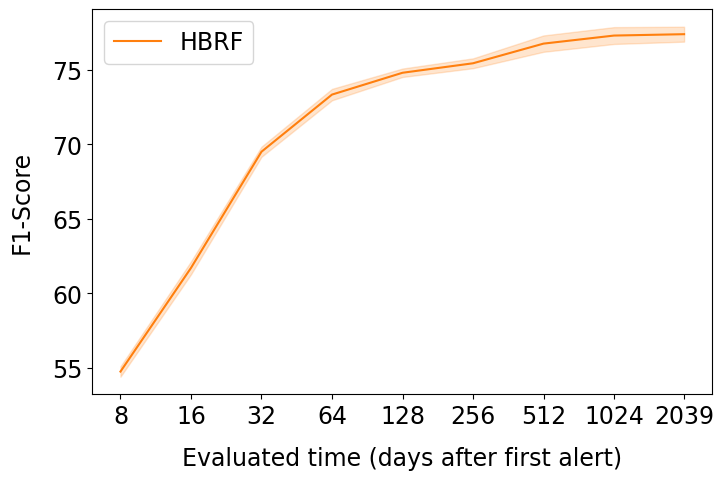

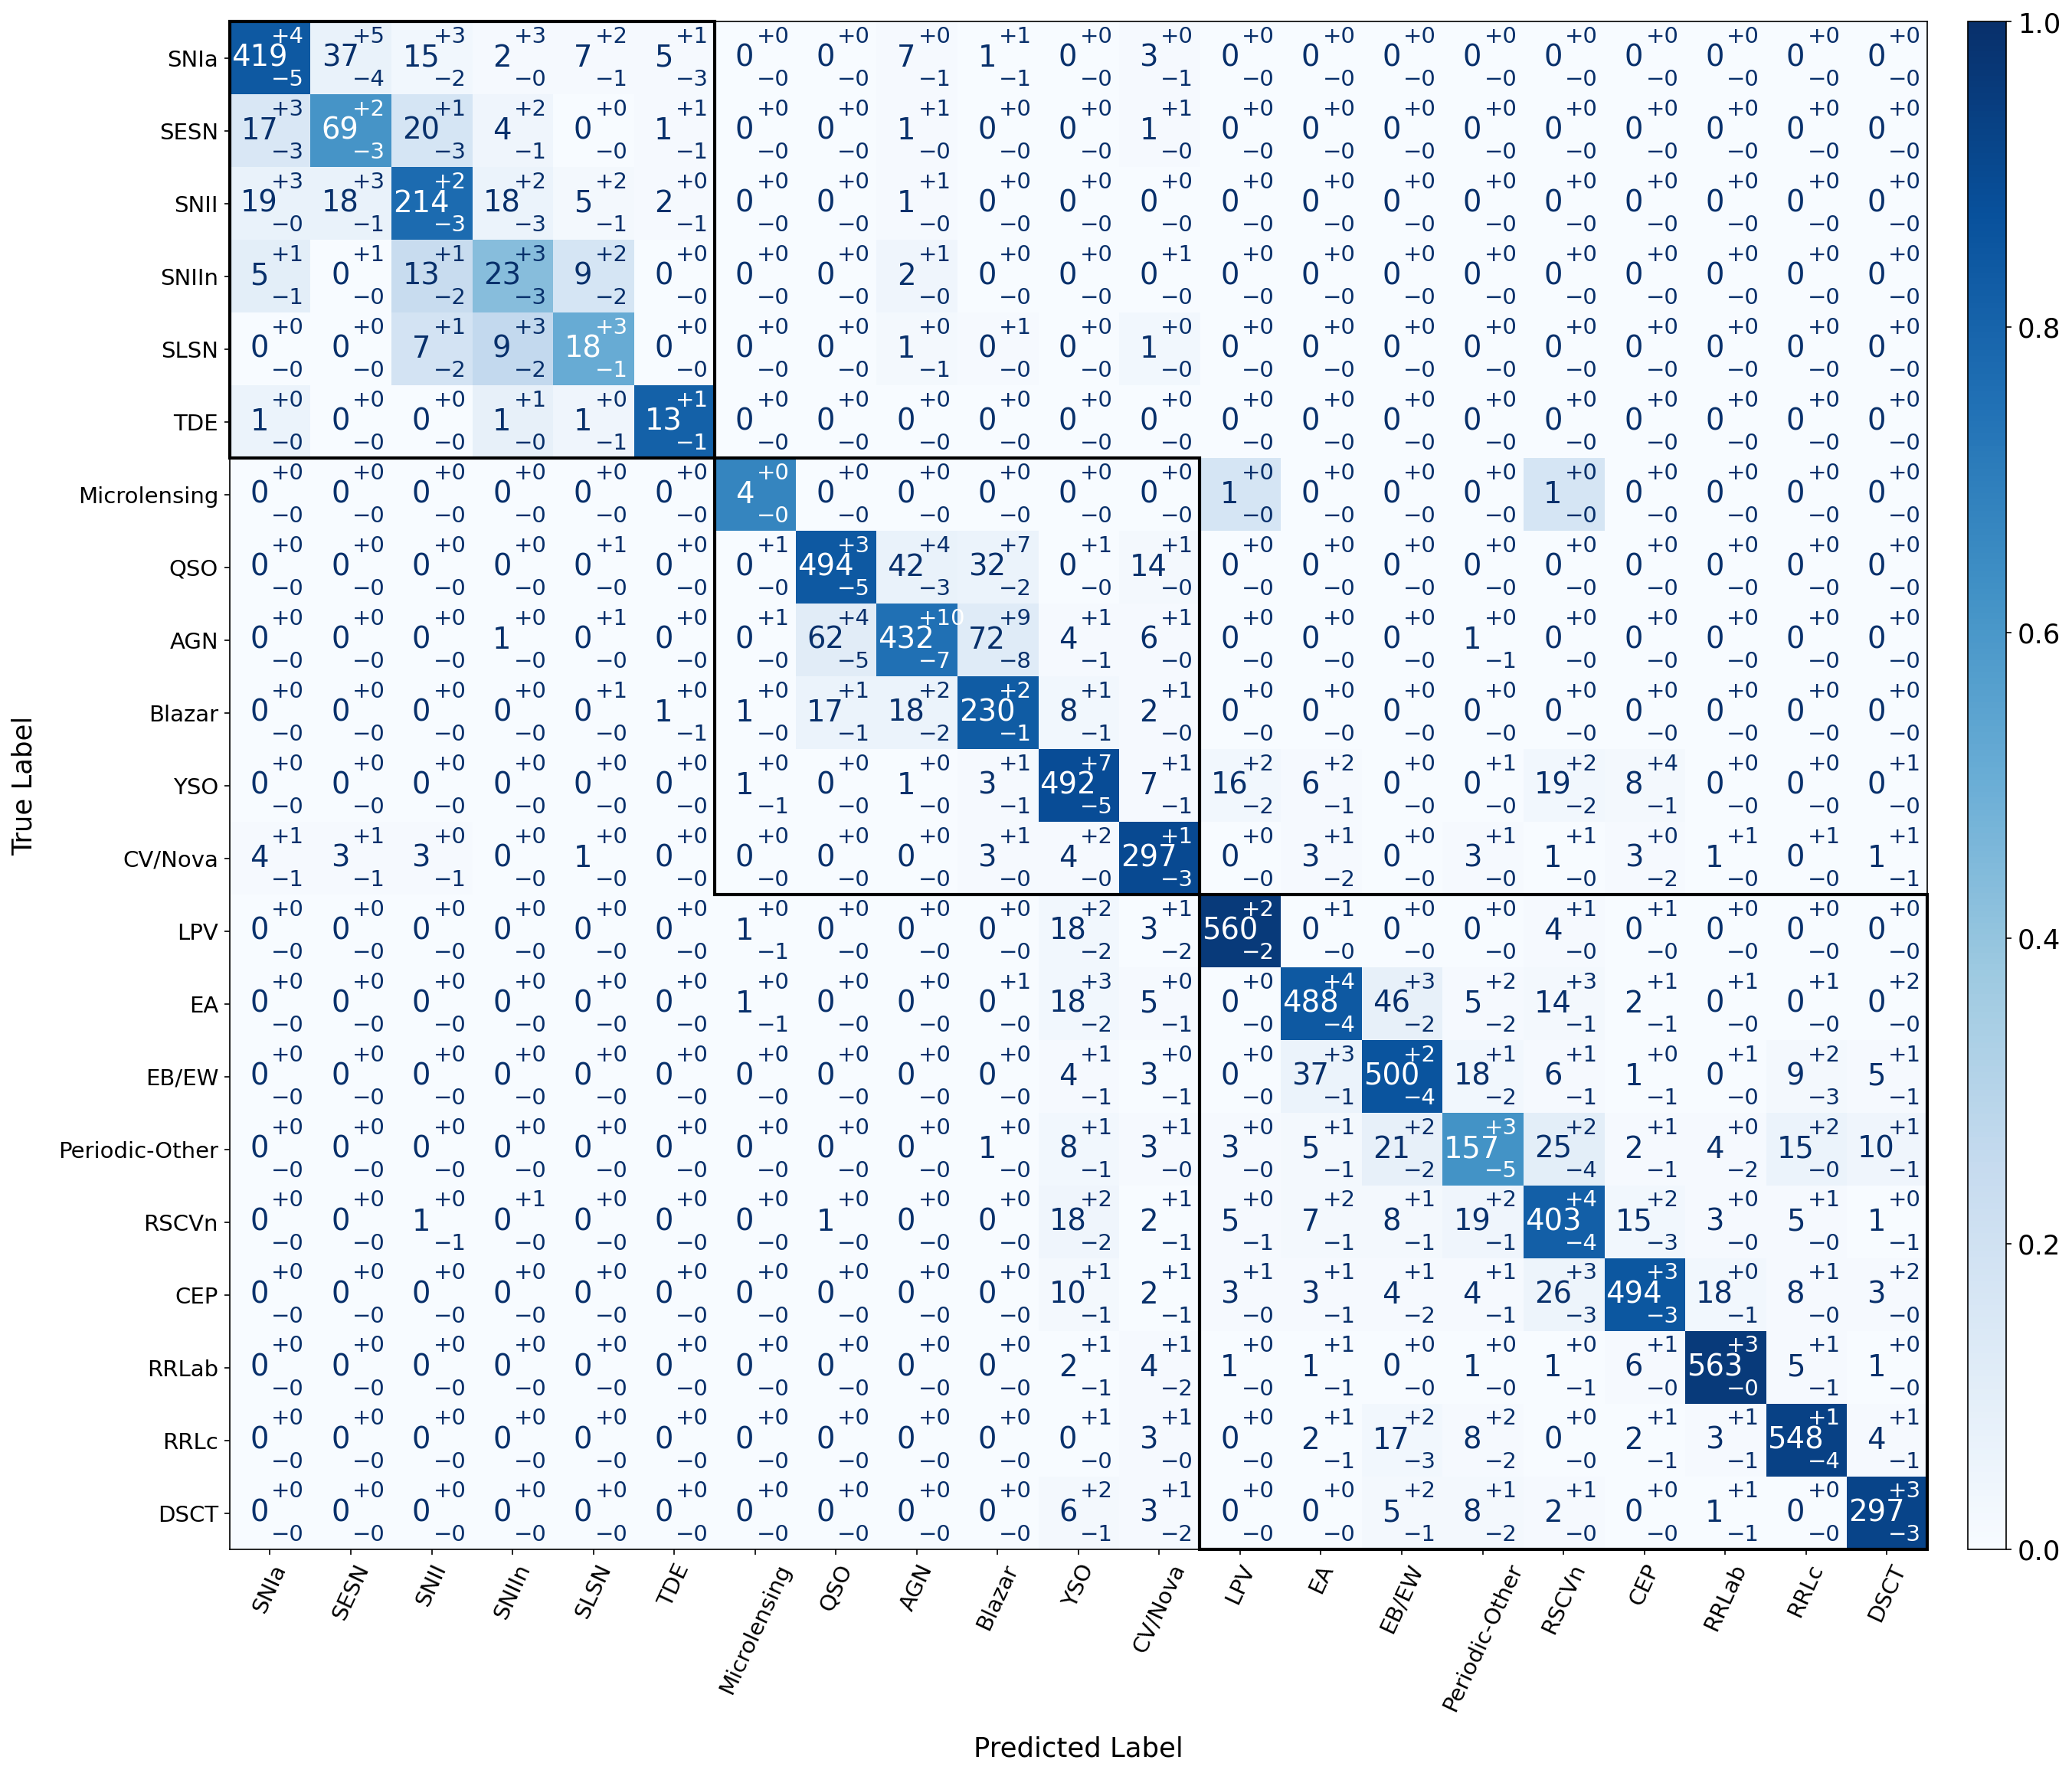

In [1]:
%cd ../

import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import warnings
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.patches as patches

# Configuración inicial
warnings.filterwarnings('ignore')

order_classes = [
    "SNIa", "SESN", "SNII", "SNIIn", "SLSN", 
    "TDE", "Microlensing", "QSO", "AGN", "Blazar", 
    "YSO", "CV/Nova", "LPV", "EA", "EB/EW", 
    "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT"
]

class_hierarchy = {
    "Transient": ["SNIa", "SESN", "SNII", "SNIIn", "SLSN", "TDE"],
    "Periodic": ["LPV", "EA", "EB/EW", "Periodic-Other", "RSCVn", "CEP", "RRLab", "RRLc", "DSCT"],
    "Stochastic": ["QSO", "AGN", "Blazar", "YSO", "CV/Nova", "Microlensing"],
}

# Lista de días evaluados
list_time_eval = ['8', '16', '32', '64', '128', '256', '512', '1024', 'None']

path_save_imgs = 'images'
os.makedirs(f'{path_save_imgs}', exist_ok=True)

# Inicializar estructuras para almacenar resultados solo de HBRF
hbrf_y_pred_fold = {}
y_test_fold = {}

# Asumimos 20 folds (0 a 19) basado en el nombre de tu archivo 'ztf_ff_20folds'
folds_range = range(20) 

print("Iniciando procesamiento de HBRF...")

# ---------------------------------------------------------
# CARGA DE DATOS (SOLO HBRF)
# ---------------------------------------------------------
for time_eval in list_time_eval:
    hbrf_y_pred_fold[f'{time_eval}_days'] = []
    y_test_fold[f'{time_eval}_days'] = []  # Guardar valores reales (y_true)

    for fold in folds_range:
        # Cargar predicciones de HBRF
        # Asegúrate de que esta ruta sea la correcta en tu sistema
        root = 'models/HBRF/results/250408_ndetge8_20folds/HBRF_20251229-182152'
        path_hbrf = f'{root}/fold_{fold}/predictions_test.parquet'
        
        try:
            hbrf_df_predictions = pd.read_parquet(path_hbrf)
        except FileNotFoundError:
            print(f"Advertencia: No se encontró el archivo para el fold {fold} en {path_hbrf}")
            continue

        # Filtrar por tiempo de evaluación
        hbrf_df_predictions = hbrf_df_predictions[hbrf_df_predictions['shorten'] == time_eval]
        
        # Procesar índice (OID)
        hbrf_df_predictions.index = hbrf_df_predictions.index.astype(str).str.split('_').str[1]
        
        # Obtener predicciones y valores reales
        # IMPORTANTE: Asumimos que el parquet de HBRF tiene la columna 'y_true'
        if 'y_true' not in hbrf_df_predictions.columns:
             raise ValueError(f"El archivo de HBRF en fold {fold} no contiene la columna 'y_true'.")
             
        y_test = hbrf_df_predictions['y_true'].values
        hbrf_y_pred = hbrf_df_predictions['y_pred'].values

        # Guardar valores en estructuras
        hbrf_y_pred_fold[f'{time_eval}_days'].append(hbrf_y_pred)
        y_test_fold[f'{time_eval}_days'].append(y_test)

print("Carga de datos finalizada.")

# ---------------------------------------------------------
# CÁLCULO DE MÉTRICAS
# ---------------------------------------------------------
metrics_by_time = {time_eval: {"HBRF": []} for time_eval in list_time_eval}
confusion_matrices = {} 

for time_eval in list_time_eval:
    # Verificar si hay datos cargados para este tiempo
    if len(y_test_fold[f"{time_eval}_days"]) == 0:
        continue

    for fold in range(len(y_test_fold[f"{time_eval}_days"])):  # Iterar sobre los folds disponibles
        y_test = y_test_fold[f"{time_eval}_days"][fold]
        y_pred_hbrf = hbrf_y_pred_fold[f"{time_eval}_days"][fold]

        # Calcular reporte de métricas inter
        report_hbrf_inter = classification_report(y_test, y_pred_hbrf, output_dict=True)

        # Guardar métricas
        metrics_by_time[time_eval]["HBRF"].append(report_hbrf_inter)

        # Guardar matrices de confusión solo cuando time_eval es None (LC completa)
        if time_eval == 'None':
            if time_eval not in confusion_matrices:
                confusion_matrices[time_eval] = {"HBRF": []}
            
            cm_hbrf = confusion_matrix(y_test, y_pred_hbrf, labels=order_classes)
            confusion_matrices[time_eval]["HBRF"].append(cm_hbrf)

# ---------------------------------------------------------
# CREACIÓN DE TABLAS (DATAFRAMES)
# ---------------------------------------------------------
# Diccionario dinámico para almacenar los datos de cada categoría
data_inter = {category: [] for category in order_classes}
data_inter_macro = []

for time_eval in list_time_eval:
    if not metrics_by_time[time_eval]["HBRF"]: continue

    for category in order_classes:
        row = [time_eval]
        # Solo HBRF
        recalls = [metrics_by_time[time_eval]["HBRF"][fold][category]["recall"] * 100 
                   for fold in range(len(metrics_by_time[time_eval]["HBRF"]))]
        precision = [metrics_by_time[time_eval]["HBRF"][fold][category]["precision"] * 100 
                     for fold in range(len(metrics_by_time[time_eval]["HBRF"]))]
        f1_score = [metrics_by_time[time_eval]["HBRF"][fold][category]["f1-score"] * 100 
                    for fold in range(len(metrics_by_time[time_eval]["HBRF"]))]

        row.extend([
            f"{np.mean(precision):.2f} ± {np.std(precision):.2f}",
            f"{np.mean(recalls):.2f} ± {np.std(recalls):.2f}",
            f"{np.mean(f1_score):.2f} ± {np.std(f1_score):.2f}"
        ])

        data_inter[category].append(row)

    # Calcular y guardar macro promedio por cada time_eval
    row_macro = [time_eval]
    
    macro_precision = [metrics_by_time[time_eval]["HBRF"][fold]["macro avg"]["precision"] * 100 
                       for fold in range(len(metrics_by_time[time_eval]["HBRF"]))]
    macro_recall = [metrics_by_time[time_eval]["HBRF"][fold]["macro avg"]["recall"] * 100 
                    for fold in range(len(metrics_by_time[time_eval]["HBRF"]))]
    macro_f1 = [metrics_by_time[time_eval]["HBRF"][fold]["macro avg"]["f1-score"] * 100 
                for fold in range(len(metrics_by_time[time_eval]["HBRF"]))]

    row_macro.extend([
        f"{np.mean(macro_precision)} ± {np.std(macro_precision)}",
        f"{np.mean(macro_recall)} ± {np.std(macro_recall)}",
        f"{np.mean(macro_f1)} ± {np.std(macro_f1)}"
    ])
    
    data_inter_macro.append(row_macro)

# Crear DataFrames
columns = ["Time (days)", "HBRF Precision", "HBRF Recall", "HBRF F1-score"]

df_inter = {category: pd.DataFrame(data, columns=columns).set_index("Time (days)") 
            for category, data in data_inter.items()}

df_inter_macro = pd.DataFrame(data_inter_macro, columns=columns).set_index("Time (days)")

# MOSTRAR RESULTADOS
display(df_inter_macro.head())
print(f'Number of classes: {len(df_inter)}')


# ---------------------------------------------------------
# GRAFICAR F1-SCORE (SOLO HBRF)
# ---------------------------------------------------------
def get_mean_std(list_values):
    means = []
    std_devs = []
    for values in list_values:
        mean, std_dev = values.split(" ± ")
        means.append(float(mean))
        std_devs.append(float(std_dev))
    return means, std_devs

hbrf_f1, hbrf_f1_err =  get_mean_std(df_inter_macro['HBRF F1-score'].values)
days = [int(k) if k != 'None' else 2039 for k in df_inter_macro.index.values]

fig, ax = plt.subplots(figsize=(8, 5))

# Graficar solo HBRF
ax.plot(days, hbrf_f1, linestyle='-', label='HBRF', color='tab:orange')
ax.fill_between(days, np.array(hbrf_f1) - np.array(hbrf_f1_err), np.array(hbrf_f1) + np.array(hbrf_f1_err), color='tab:orange', alpha=0.2)

# Configurar el eje X con escala logarítmica en base 2
list_time_to_eval = sorted(days)
ax.set_xscale('log', base=2)
ax.set_xticks(list_time_to_eval)

fs = 17
ax.set_xlabel('Evaluated time (days after first alert)', fontsize=fs, labelpad=13)
ax.set_ylabel('F1-Score', fontsize=fs, labelpad=13)
ax.tick_params(axis='y', labelsize=fs)
ax.set_xticklabels(list_time_to_eval, fontsize=fs)
ax.legend(fontsize=fs)

plt.savefig(f"{path_save_imgs}/eval_time_bottom_lvl_new_tax_hbrf.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ---------------------------------------------------------
# MATRIZ DE CONFUSIÓN (SOLO HBRF)
# ---------------------------------------------------------
def get_confusion_matrix(matrices, order_classes, class_hierarchy=None, path_save=None, figsize=(13, 13), shrink=0.675):
    if not matrices:
        print("No hay matrices para graficar.")
        return
        
    median_matrix = np.median(matrices, axis=0)
    p5_matrix = np.abs(median_matrix - np.percentile(matrices, 5, axis=0))
    p95_matrix = np.abs(median_matrix - np.percentile(matrices, 95, axis=0)) 

    matrices_norm = np.array([m / m.sum(axis=1, keepdims=True) for m in matrices])
    matrices_norm = np.nan_to_num(matrices_norm)
    mean_matrices_norm = np.mean(matrices_norm, axis=0)
        
    cmap = plt.cm.Blues
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    im = ax.imshow(np.around(mean_matrices_norm, decimals=2), interpolation='nearest', cmap=cmap, aspect=.9, vmax=1)

    cbar = plt.colorbar(im, ax=ax, pad=0.02, aspect=40, shrink=shrink)
    cbar.ax.tick_params(labelsize=17)

    new_color = cmap(1.0) 

    for i in range(median_matrix.shape[0]):
        for j in range(median_matrix.shape[1]):
            mean_val = int(median_matrix[i, j])
            p5_val = int(p5_matrix[i, j])
            p95_val = int(p95_matrix[i, j])

            text = f'{mean_val}'
            text_p95 = f'+{p95_val}' 
            text_p5 = f'−{p5_val}' 

            color = "white" if mean_matrices_norm[i, j] > 0.5 else new_color

            ax.text(j - 0.13, i, text, ha="center", va="center", color=color, fontsize=18.5)
            ax.text(j + 0.018, i - 0.15, text_p95, ha="left", va="bottom", color=color, fontsize=14)
            ax.text(j + 0.018, i + 0.15, text_p5, ha="left", va="top", color=color, fontsize=14)

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(np.arange(len(order_classes)))
    ax.set_yticks(np.arange(len(order_classes)))
    ax.set_xticklabels(order_classes)
    ax.set_yticklabels(order_classes)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right", rotation_mode="anchor")

    ax.xaxis.label.set_size(16)
    ax.yaxis.label.set_size(16)
    ax.xaxis.labelpad = 13
    ax.yaxis.labelpad = 13

    if class_hierarchy is not None:
        for class_list in class_hierarchy.values():
            indices = [order_classes.index(cls) for cls in class_list if cls in order_classes]
            if indices:
                min_idx, max_idx = min(indices), max(indices)
                rect = patches.Rectangle(
                    (min_idx - 0.5, min_idx - 0.5), 
                    max_idx - min_idx + 1, 
                    max_idx - min_idx + 1, 
                    linewidth=2, edgecolor="black", facecolor='none', clip_on=False
                )
                ax.add_patch(rect)

    ax.set_ylabel('True Label', fontsize=17)
    ax.set_xlabel('Predicted Label', fontsize=17)

    plt.setp(ax.get_xticklabels(), rotation=65, ha='center', va='top', rotation_mode="default")
    plt.tight_layout()

    if path_save is not None:
        plt.savefig(f"{path_save}", format="pdf", bbox_inches="tight")

    plt.show()

# Graficar Matriz de HBRF si existe
if 'None' in confusion_matrices and 'HBRF' in confusion_matrices['None']:
    matrices = confusion_matrices['None']['HBRF']
    path_save = f'{path_save_imgs}/cm_hbrf_bottom_lvl_new_tax.pdf'
    get_confusion_matrix(matrices, order_classes, class_hierarchy=class_hierarchy, path_save=path_save, figsize=(20,20), shrink=0.675)
else:
    print("No se encontraron datos para la matriz de confusión (None days).")